<a href="https://colab.research.google.com/github/whydonotme/trading-lab/blob/main/notebooks/portfel_fib_bos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pobieranie danych dla QQQ...


[*********************100%***********************]  1 of 1 completed



RAPORT STRATEGII QUANT (NASDAQ 1H):
Początkowy kapitał:    $100,000.00
Końcowy kapitał:       $114,000.00
Łączny zwrot:          14.00%
Liczba transakcji:     43
Skuteczność (Win Rate):44.19%
Profit Factor:         1.58
Maksymalne obsunięcie: 4.24%


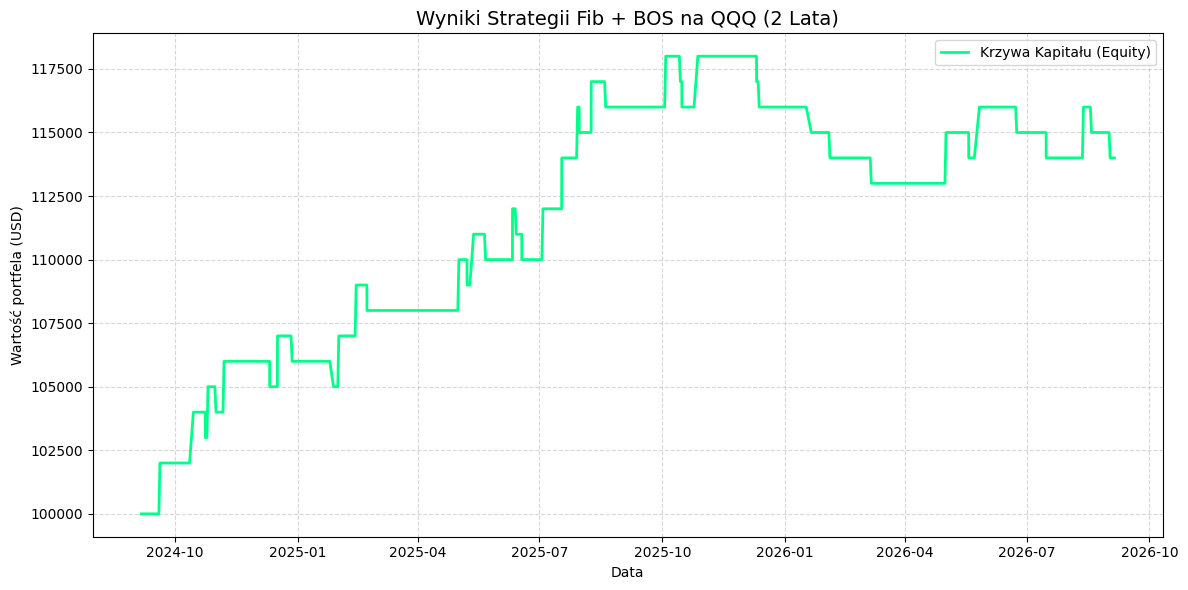

In [ ]:
# 1. Instalacja i pobranie bibliotek
!pip install yfinance matplotlib pandas numpy -q

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 2. Pobranie danych Nasdaq (QQQ) - 2 lata, interwał 1H
ticker = "QQQ"
print(f"Pobieranie danych dla {ticker}...")
df = yf.download(ticker, period="2y", interval="1h", auto_adjust=True)

# Czyszczenie nagłówków (kompatybilność z nowym yfinance)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# 3. Wskaźniki techniczne: EMA 200, Swingi, ATR
df['EMA200'] = df['Close'].ewm(span=200, adjust=False).mean()

# Wyznaczanie swingów z ostatnich 30 świec
lookback = 30
df['SwingHigh'] = df['High'].rolling(window=lookback).max()
df['SwingLow'] = df['Low'].rolling(window=lookback).min()
df['Range'] = df['SwingHigh'] - df['SwingLow']

# Poziomy Fibonacciego
df['Fib382'] = df['SwingHigh'] - (df['Range'] * 0.382)
df['Fib618'] = df['SwingHigh'] - (df['Range'] * 0.618)

# ATR do wyznaczania bufora Stop Loss
high_low = df['High'] - df['Low']
high_close = np.abs(df['High'] - df['Close'].shift())
low_close = np.abs(df['Low'] - df['Close'].shift())
tr = np.maximum(high_low, np.maximum(high_close, low_close))
df['ATR'] = tr.rolling(14).mean()

# Formacja Bullish Engulfing
df['BullEngulf'] = (df['Close'] > df['Open']) & \
                   (df['Close'].shift(1) < df['Open'].shift(1)) & \
                   (df['Close'] >= df['Open'].shift(1))

# 4. Warunki wejścia (Long)
# Trend wzrostowy (Close > EMA200) + cena w strefie Fib (38.2% - 61.8%) + Engulfing
df['Signal'] = (df['Close'] > df['EMA200']) & \
               (df['Low'] <= df['Fib382']) & \
               (df['Low'] >= df['Fib618']) & \
               df['BullEngulf']

# 5. Silnik Backtestingu (Risk/Reward 1:2)
initial_capital = 100000.0
capital = initial_capital
equity_curve = []
trades = []

position_open = False
entry_price = 0.0
stop_loss = 0.0
take_profit = 0.0
rr_ratio = 2.0
risk_per_trade = 1000.0  # Stałe ryzyko 1 000 USD na trejd (1% konta)

for i in range(len(df)):
    current_time = df.index[i]
    current_close = df['Close'].iloc[i]
    current_high = df['High'].iloc[i]
    current_low = df['Low'].iloc[i]
    current_atr = df['ATR'].iloc[i]
    signal = df['Signal'].iloc[i]

    if position_open:
        # Sprawdzenie Take Profit
        if current_high >= take_profit:
            profit = risk_per_trade * rr_ratio
            capital += profit
            trades.append(profit)
            position_open = False
        # Sprawdzenie Stop Loss
        elif current_low <= stop_loss:
            loss = -risk_per_trade
            capital += loss
            trades.append(loss)
            position_open = False

    elif not position_open and signal and not np.isnan(current_atr):
        # Wejście w pozycję
        entry_price = current_close
        stop_loss = current_low - (current_atr * 1.0)
        sl_distance = entry_price - stop_loss

        if sl_distance > 0:
            take_profit = entry_price + (sl_distance * rr_ratio)
            position_open = True

    equity_curve.append(capital)

df['Equity'] = equity_curve

# 6. Kalkulacja statystyk
total_trades = len(trades)
wins = [t for t in trades if t > 0]
losses = [t for t in trades if t < 0]

win_rate = (len(wins) / total_trades * 100) if total_trades > 0 else 0
gross_profit = sum(wins) if wins else 0
gross_loss = abs(sum(losses)) if losses else 0
profit_factor = (gross_profit / gross_loss) if gross_loss > 0 else np.nan

# Maksymalne obsunięcie kapitału (Drawdown)
equity_series = pd.Series(equity_curve)
drawdown = (equity_series - equity_series.cummax()) / equity_series.cummax() * 100
max_drawdown = abs(drawdown.min())

# Wyświetlenie wyników
print("\n" + "="*40)
print(f"RAPORT STRATEGII QUANT (NASDAQ 1H):")
print(f"Początkowy kapitał:    ${initial_capital:,.2f}")
print(f"Końcowy kapitał:       ${capital:,.2f}")
print(f"Łączny zwrot:          {((capital - initial_capital) / initial_capital) * 100:.2f}%")
print(f"Liczba transakcji:     {total_trades}")
print(f"Skuteczność (Win Rate):{win_rate:.2f}%")
print(f"Profit Factor:         {profit_factor:.2f}")
print(f"Maksymalne obsunięcie: {max_drawdown:.2f}%")
print("="*40)

# 7. Wykres krzywej kapitału
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Equity'], label="Krzywa Kapitału (Equity)", color="#00ff88", linewidth=2)
plt.title(f"Wyniki Strategii Fib + BOS na {ticker} (2 Lata)", fontsize=14)
plt.xlabel("Data")
plt.ylabel("Wartość portfela (USD)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Szybki Grid Search: optymalizacja parametrów w kilka sekund
results = []

lookbacks = [20, 30, 40]
rr_ratios = [1.5, 2.0, 2.5]
atr_mults = [0.8, 1.0, 1.5, 2.0]

for lb in lookbacks:
    # Przeliczenie poziomów swingu i Fibonacciego
    s_high = df['High'].rolling(window=lb).max()
    s_low = df['Low'].rolling(window=lb).min()
    s_range = s_high - s_low
    fib382 = s_high - (s_range * 0.382)
    fib618 = s_high - (s_range * 0.618)

    sig = (df['Close'] > df['EMA200']) & (df['Low'] <= fib382) & (df['Low'] >= fib618) & df['BullEngulf']

    for rr in rr_ratios:
        for mult in atr_mults:
            cap = 100000.0
            pos = False
            sl, tp = 0.0, 0.0
            w, l = 0, 0

            for i in range(len(df)):
                c_close = df['Close'].iloc[i]
                c_high = df['High'].iloc[i]
                c_low = df['Low'].iloc[i]
                c_atr = df['ATR'].iloc[i]

                if pos:
                    if c_high >= tp:
                        cap += 1000.0 * rr
                        w += 1
                        pos = False
                    elif c_low <= sl:
                        cap -= 1000.0
                        l += 1
                        pos = False
                elif not pos and sig.iloc[i] and not np.isnan(c_atr):
                    sl = c_low - (c_atr * mult)
                    dist = c_close - sl
                    if dist > 0:
                        tp = c_close + (dist * rr)
                        pos = True

            tot = w + l
            if tot >= 20: # Min. 20 transakcji
                pf = (w * 1000.0 * rr) / (l * 1000.0) if l > 0 else np.nan
                results.append({
                    'Lookback': lb, 'RR': rr, 'ATR_Mult': mult,
                    'Zysk ($)': round(cap - 100000.0, 2),
                    'Transakcje': tot,
                    'WinRate (%)': round(w / tot * 100, 1),
                    'ProfitFactor': round(pf, 2)
                })

# Tabela 5 najlepszych konfiguracji
res_df = pd.DataFrame(results).sort_values(by='ProfitFactor', ascending=False)
print("TOP 5 NAJBARDZIEJ ZYSKOWNYCH KONFIGURACJI:")
print(res_df.head(5).to_string(index=False))


TOP 5 NAJBARDZIEJ ZYSKOWNYCH KONFIGURACJI:
 Lookback  RR  ATR_Mult  Zysk ($)  Transakcje  WinRate (%)  ProfitFactor
       20 2.5       1.0   28500.0          38         50.0          2.50
       30 2.5       1.0   26500.0          40         47.5          2.26
       40 2.5       1.0   25000.0          38         47.4          2.25
       20 2.5       1.5   19000.0          30         46.7          2.19
       20 2.0       1.5   18000.0          33         51.5          2.12


WYNIKI SYMULACJI MONTE CARLO (1000 SCENARIUSZY):
Prawdopodobieństwo zysku:         99.7%
Mediana zysku:                    $28,500.00
Mediana Max Drawdown:             3.86%
95% Worst-Case Drawdown (VaR):    7.38%
Ryzyko obsunięcia powyżej 15%:    0.0%


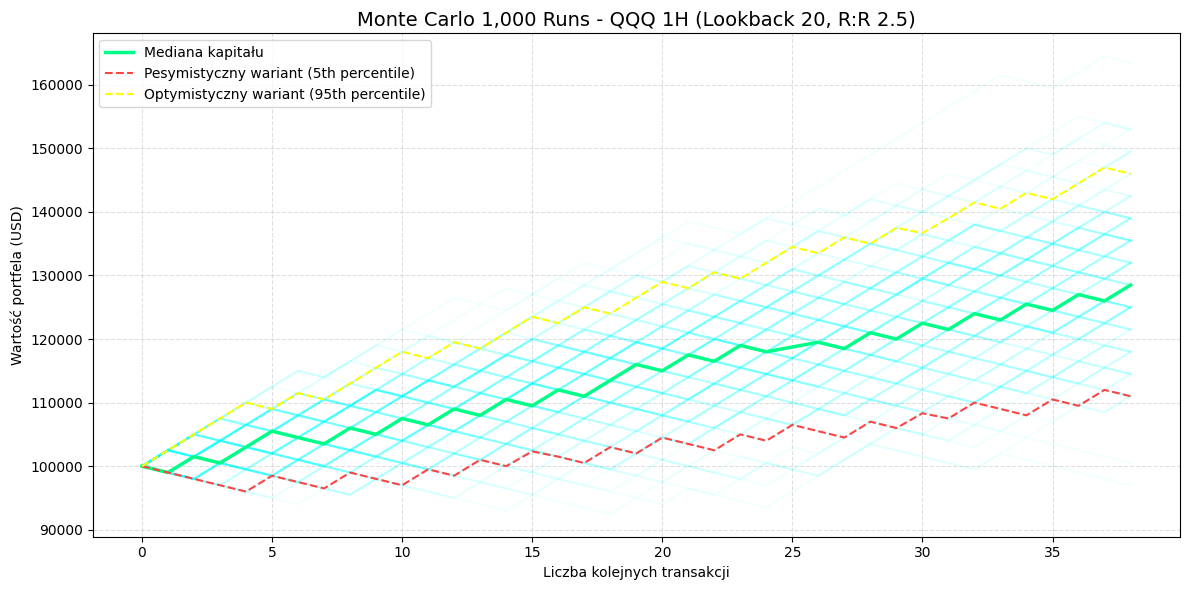

In [ ]:
import random

# 1. Wygenerowanie listy transakcji dla konfiguracji TOP 1 (Lookback: 20, RR: 2.5, ATR: 1.0)
lb = 20
rr = 2.5
mult = 1.0

s_high = df['High'].rolling(window=lb).max()
s_low = df['Low'].rolling(window=lb).min()
s_range = s_high - s_low
fib382 = s_high - (s_range * 0.382)
fib618 = s_high - (s_range * 0.618)

sig = (df['Close'] > df['EMA200']) & (df['Low'] <= fib382) & (df['Low'] >= fib618) & df['BullEngulf']

trade_returns = []
pos = False
sl, tp = 0.0, 0.0

for i in range(len(df)):
    c_close = df['Close'].iloc[i]
    c_high = df['High'].iloc[i]
    c_low = df['Low'].iloc[i]
    c_atr = df['ATR'].iloc[i]

    if pos:
        if c_high >= tp:
            trade_returns.append(1000.0 * rr) # Zysk +2500 USD
            pos = False
        elif c_low <= sl:
            trade_returns.append(-1000.0)      # Strata -1000 USD
            pos = False
    elif not pos and sig.iloc[i] and not np.isnan(c_atr):
        sl = c_low - (c_atr * mult)
        dist = c_close - sl
        if dist > 0:
            tp = c_close + (dist * rr)
            pos = True

# 2. Silnik symulacji Monte Carlo (1000 prób)
num_simulations = 1000
num_trades = len(trade_returns)
starting_capital = 100000.0

simulated_curves = np.zeros((num_simulations, num_trades + 1))
simulated_curves[:, 0] = starting_capital
max_drawdowns = []

for sim in range(num_simulations):
    # Losowanie ze zwracaniem (Bootstrapping)
    shuffled_trades = np.random.choice(trade_returns, size=num_trades, replace=True)
    equity = starting_capital
    curve = [equity]
    peak = equity
    drawdowns = []

    for tr in shuffled_trades:
        equity += tr
        curve.append(equity)
        if equity > peak:
            peak = equity
        dd = (peak - equity) / peak * 100
        drawdowns.append(dd)

    simulated_curves[sim, :] = curve
    max_drawdowns.append(max(drawdowns))

# 3. Metryki ryzyka
max_drawdowns = np.array(max_drawdowns)
final_equities = simulated_curves[:, -1]

dd_95th = np.percentile(max_drawdowns, 95)
median_dd = np.median(max_drawdowns)
median_profit = np.median(final_equities) - starting_capital
prob_profit = (np.sum(final_equities > starting_capital) / num_simulations) * 100
risk_of_ruin_15dd = (np.sum(max_drawdowns > 15.0) / num_simulations) * 100

print("="*45)
print("WYNIKI SYMULACJI MONTE CARLO (1000 SCENARIUSZY):")
print(f"Prawdopodobieństwo zysku:         {prob_profit:.1f}%")
print(f"Mediana zysku:                    ${median_profit:,.2f}")
print(f"Mediana Max Drawdown:             {median_dd:.2f}%")
print(f"95% Worst-Case Drawdown (VaR):    {dd_95th:.2f}%")
print(f"Ryzyko obsunięcia powyżej 15%:    {risk_of_ruin_15dd:.1f}%")
print("="*45)

# 4. Wykres wiązkowy (Fan Chart)
plt.figure(figsize=(12, 6))
# Rysujemy losowe 150 ścieżek z 1000 dla przejrzystości
for i in range(150):
    plt.plot(simulated_curves[i], color="cyan", alpha=0.05)

plt.plot(np.median(simulated_curves, axis=0), color="#00ff88", linewidth=2.5, label="Mediana kapitału")
plt.plot(np.percentile(simulated_curves, 5, axis=0), color="#ff4444", linestyle="--", linewidth=1.5, label="Pesymistyczny wariant (5th percentile)")
plt.plot(np.percentile(simulated_curves, 95, axis=0), color="#ffff00", linestyle="--", linewidth=1.5, label="Optymistyczny wariant (95th percentile)")

plt.title("Monte Carlo 1,000 Runs - QQQ 1H (Lookback 20, R:R 2.5)", fontsize=14)
plt.xlabel("Liczba kolejnych transakcji")
plt.ylabel("Wartość portfela (USD)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Pobranie danych 15-minutowych dla QQQ (ostatnie 60 dni roboczych)
df_15m = yf.download("QQQ", period="60d", interval="15m", auto_adjust=True)
if isinstance(df_15m.columns, pd.MultiIndex):
    df_15m.columns = df_15m.columns.get_level_values(0)

# Wskaźniki techniczne pod daytrading 15m
df_15m['EMA200'] = df_15m['Close'].ewm(span=200, adjust=False).mean()

lb_15 = 20
df_15m['SwingHigh'] = df_15m['High'].rolling(window=lb_15).max()
df_15m['SwingLow'] = df_15m['Low'].rolling(window=lb_15).min()
df_15m['Range'] = df_15m['SwingHigh'] - df_15m['SwingLow']

df_15m['Fib382'] = df_15m['SwingHigh'] - (df_15m['Range'] * 0.382)
df_15m['Fib618'] = df_15m['SwingHigh'] - (df_15m['Range'] * 0.618)

# ATR i formacja objęcia
h_l = df_15m['High'] - df_15m['Low']
h_c = np.abs(df_15m['High'] - df_15m['Close'].shift())
l_c = np.abs(df_15m['Low'] - df_15m['Close'].shift())
df_15m['ATR'] = np.maximum(h_l, np.maximum(h_c, l_c)).rolling(14).mean()

df_15m['BullEngulf'] = (df_15m['Close'] > df_15m['Open']) & \
                       (df_15m['Close'].shift(1) < df_15m['Open'].shift(1)) & \
                       (df_15m['Close'] >= df_15m['Open'].shift(1))

# Warunki sygnału
df_15m['Signal'] = (df_15m['Close'] > df_15m['EMA200']) & \
                   (df_15m['Low'] <= df_15m['Fib382']) & \
                   (df_15m['Low'] >= df_15m['Fib618']) & \
                   df_15m['BullEngulf']

# Symulacja dla konta 3 000 USD (Ryzyko 30 USD na SL, R:R 1:2.5)
cap_3k = 3000.0
trades_15m = []
pos = False
sl, tp = 0.0, 0.0
risk_usd = 30.0
rr = 2.5

for i in range(len(df_15m)):
    c_close = df_15m['Close'].iloc[i]
    c_high = df_15m['High'].iloc[i]
    c_low = df_15m['Low'].iloc[i]
    c_atr = df_15m['ATR'].iloc[i]
    sig = df_15m['Signal'].iloc[i]

    if pos:
        if c_high >= tp:
            cap_3k += risk_usd * rr
            trades_15m.append(risk_usd * rr)
            pos = False
        elif c_low <= sl:
            cap_3k -= risk_usd
            trades_15m.append(-risk_usd)
            pos = False
    elif not pos and sig and not np.isnan(c_atr):
        sl = c_low - (c_atr * 1.0)
        dist = c_close - sl
        if dist > 0:
            tp = c_close + (dist * rr)
            pos = True

wins_15m = [t for t in trades_15m if t > 0]
losses_15m = [t for t in trades_15m if t < 0]
total_t = len(trades_15m)
pf_15m = (sum(wins_15m) / abs(sum(losses_15m))) if losses_15m else 0

print("="*40)
print("WYNIKI DAYTRADINGU 15M (KONTO 3 000 USD):")
print(f"Końcowy kapitał:        ${cap_3k:,.2f}")
print(f"Zysk netto (60 dni):    ${cap_3k - 3000.0:,.2f}")
print(f"Liczba transakcji:      {total_t} (ok. {total_t / 8.5:.1f} na tydzień)")
print(f"Skuteczność:            {(len(wins_15m)/total_t*100):.1f}%" if total_t > 0 else "0%")
print(f"Profit Factor:          {pf_15m:.2f}")
print("="*40)


[*********************100%***********************]  1 of 1 completed

WYNIKI DAYTRADINGU 15M (KONTO 3 000 USD):
Końcowy kapitał:        $3,135.00
Zysk netto (60 dni):    $135.00
Liczba transakcji:      6 (ok. 0.7 na tydzień)
Skuteczność:            50.0%
Profit Factor:          2.50


In [ ]:
# Test Multi-Asset (Long + Short) na interwale 15m
tickers = ["QQQ", "SPY"]
risk_usd = 30.0  # 1% z 3 000 USD
rr = 2.5
combined_trades = []

print("Rozpoczynam test dla koszyka aktywów (Long + Short)...")

for sym in tickers:
    data = yf.download(sym, period="60d", interval="15m", auto_adjust=True)
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    data['EMA200'] = data['Close'].ewm(span=200, adjust=False).mean()

    # Swingi
    s_h = data['High'].rolling(20).max()
    s_l = data['Low'].rolling(20).min()
    rng = s_h - s_l

    # Fib Long (zniesienie w trendzie wzrostowym)
    f382_l = s_h - (rng * 0.382)
    f618_l = s_h - (rng * 0.650)

    # Fib Short (odbicie w trendzie spadkowym)
    f382_s = s_l + (rng * 0.382)
    f618_s = s_l + (rng * 0.650)

    # ATR
    hl = data['High'] - data['Low']
    hc = np.abs(data['High'] - data['Close'].shift())
    lc = np.abs(data['Low'] - data['Close'].shift())
    data['ATR'] = np.maximum(hl, np.maximum(hc, lc)).rolling(14).mean()

    # Świece objęcia
    bull_eng = (data['Close'] > data['Open']) & (data['Close'].shift(1) < data['Open'].shift(1)) & (data['Close'] >= data['Open'].shift(1))
    bear_eng = (data['Close'] < data['Open']) & (data['Close'].shift(1) > data['Open'].shift(1)) & (data['Close'] <= data['Open'].shift(1))

    # Sygnały
    sig_long = (data['Close'] > data['EMA200']) & (data['Low'] <= f382_l) & (data['Low'] >= f618_l) & bull_eng
    sig_short = (data['Close'] < data['EMA200']) & (data['High'] >= f382_s) & (data['High'] <= f618_s) & bear_eng

    # Egzekucja
    pos = 0 # 1: Long, -1: Short
    sl, tp = 0.0, 0.0

    for i in range(len(data)):
        c_close = data['Close'].iloc[i]
        c_high = data['High'].iloc[i]
        c_low = data['Low'].iloc[i]
        c_atr = data['ATR'].iloc[i]

        if pos == 1: # Prowadzenie Long
            if c_high >= tp:
                combined_trades.append(risk_usd * rr)
                pos = 0
            elif c_low <= sl:
                combined_trades.append(-risk_usd)
                pos = 0
        elif pos == -1: # Prowadzenie Short
            if c_low <= tp:
                combined_trades.append(risk_usd * rr)
                pos = 0
            elif c_high >= sl:
                combined_trades.append(-risk_usd)
                pos = 0
        elif pos == 0 and not np.isnan(c_atr):
            if sig_long.iloc[i]:
                sl = c_low - (c_atr * 1.0)
                dist = c_close - sl
                if dist > 0:
                    tp = c_close + (dist * rr)
                    pos = 1
            elif sig_short.iloc[i]:
                sl = c_high + (c_atr * 1.0)
                dist = sl - c_close
                if dist > 0:
                    tp = c_close - (dist * rr)
                    pos = -1

# Wyniki łączne
total_trades = len(combined_trades)
wins = [t for t in combined_trades if t > 0]
losses = [t for t in combined_trades if t < 0]
net_pnl = sum(combined_trades)
pf = (sum(wins) / abs(sum(losses))) if losses else 0
win_rate = (len(wins) / total_trades * 100) if total_trades > 0 else 0

print("\n" + "="*45)
print("WYNIKI MULTI-ASSET 15M (LONG + SHORT, 60 DNI):")
print(f"Kapitał początkowy:    $3,000.00")
print(f"Końcowy kapitał:       ${3000.0 + net_pnl:,.2f}")
print(f"Zysk netto:            ${net_pnl:,.2f} (+{net_pnl/3000.0*100:.1f}%)")
print(f"Liczba transakcji:     {total_trades} (ok. {total_trades / 8.5:.1f} na tydzień)")
print(f"Skuteczność (Win Rate):{win_rate:.1f}%")
print(f"Profit Factor:         {pf:.2f}")
print("="*45)


Rozpoczynam test dla koszyka aktywów (Long + Short)...


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


WYNIKI MULTI-ASSET 15M (LONG + SHORT, 60 DNI):
Kapitał początkowy:    $3,000.00
Końcowy kapitał:       $3,120.00
Zysk netto:            $120.00 (+4.0%)
Liczba transakcji:     38 (ok. 4.5 na tydzień)
Skuteczność (Win Rate):31.6%
Profit Factor:         1.15


In [ ]:
# Rozbicie wyników na transakcje LONG vs SHORT
long_trades = []
short_trades = []

for sym in tickers:
    data = yf.download(sym, period="60d", interval="15m", auto_adjust=True)
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)
    data['EMA200'] = data['Close'].ewm(span=200, adjust=False).mean()
    s_h = data['High'].rolling(20).max()
    s_l = data['Low'].rolling(20).min()
    rng = s_h - s_l
    f382_l = s_h - (rng * 0.382)
    f618_l = s_h - (rng * 0.650)
    f382_s = s_l + (rng * 0.382)
    f618_s = s_l + (rng * 0.650)

    hl = data['High'] - data['Low']
    hc = np.abs(data['High'] - data['Close'].shift())
    lc = np.abs(data['Low'] - data['Close'].shift())
    data['ATR'] = np.maximum(hl, np.maximum(hc, lc)).rolling(14).mean()

    bull_eng = (data['Close'] > data['Open']) & (data['Close'].shift(1) < data['Open'].shift(1)) & (data['Close'] >= data['Open'].shift(1))
    bear_eng = (data['Close'] < data['Open']) & (data['Close'].shift(1) > data['Open'].shift(1)) & (data['Close'] <= data['Open'].shift(1))

    sig_l = (data['Close'] > data['EMA200']) & (data['Low'] <= f382_l) & (data['Low'] >= f618_l) & bull_eng
    sig_s = (data['Close'] < data['EMA200']) & (data['High'] >= f382_s) & (data['High'] <= f618_s) & bear_eng

    # Test samych Longów
    pos_l, sl_l, tp_l = False, 0.0, 0.0
    for i in range(len(data)):
        if pos_l:
            if data['High'].iloc[i] >= tp_l:
                long_trades.append(risk_usd * rr)
                pos_l = False
            elif data['Low'].iloc[i] <= sl_l:
                long_trades.append(-risk_usd)
                pos_l = False
        elif not pos_l and sig_l.iloc[i] and not np.isnan(data['ATR'].iloc[i]):
            sl_l = data['Low'].iloc[i] - data['ATR'].iloc[i]
            if data['Close'].iloc[i] - sl_l > 0:
                tp_l = data['Close'].iloc[i] + ((data['Close'].iloc[i] - sl_l) * rr)
                pos_l = True

    # Test samych Shortów
    pos_s, sl_s, tp_s = False, 0.0, 0.0
    for i in range(len(data)):
        if pos_s:
            if data['Low'].iloc[i] <= tp_s:
                short_trades.append(risk_usd * rr)
                pos_s = False
            elif data['High'].iloc[i] >= sl_s:
                short_trades.append(-risk_usd)
                pos_s = False
        elif not pos_s and sig_s.iloc[i] and not np.isnan(data['ATR'].iloc[i]):
            sl_s = data['High'].iloc[i] + data['ATR'].iloc[i]
            if sl_s - data['Close'].iloc[i] > 0:
                tp_s = data['Close'].iloc[i] - ((sl_s - data['Close'].iloc[i]) * rr)
                pos_s = True

# Wyniki
w_l = [t for t in long_trades if t > 0]
l_l = [t for t in long_trades if t < 0]
pf_l = sum(w_l) / abs(sum(l_l)) if l_l else 0

w_s = [t for t in short_trades if t > 0]
l_s = [t for t in short_trades if t < 0]
pf_s = sum(w_s) / abs(sum(l_s)) if l_s else 0

print(f"TYLKO LONG:  PnL: ${sum(long_trades):+,.2f} | Liczba transakcji: {len(long_trades)} | WinRate: {(len(w_l)/len(long_trades)*100):.1f}% | PF: {pf_l:.2f}")
print(f"TYLKO SHORT: PnL: ${sum(short_trades):+,.2f} | Liczba transakcji: {len(short_trades)} | WinRate: {(len(w_s)/len(short_trades)*100):.1f}% | PF: {pf_s:.2f}")


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


TYLKO LONG:  PnL: $+105.00 | Liczba transakcji: 14 | WinRate: 35.7% | PF: 1.39
TYLKO SHORT: PnL: $-45.00 | Liczba transakcji: 26 | WinRate: 26.9% | PF: 0.92


In [ ]:
# Koszyk: Indeksy (tylko LONG) + Złoto GLD (LONG + SHORT)
tickers_long_only = ["QQQ", "SPY"]
ticker_both = "GLD"  # Złoto (ETF GLD jako proxy dla XAUUSD)

risk_usd = 30.0
rr = 2.5
final_trades = []

# 1. Indeksy: wyłącznie pozycje LONG
for sym in tickers_long_only:
    data = yf.download(sym, period="60d", interval="15m", auto_adjust=True)
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)
    data['EMA200'] = data['Close'].ewm(span=200, adjust=False).mean()
    s_h = data['High'].rolling(20).max()
    s_l = data['Low'].rolling(20).min()
    rng = s_h - s_l
    f382_l = s_h - (rng * 0.382)
    f618_l = s_h - (rng * 0.650)

    hl = data['High'] - data['Low']
    hc = np.abs(data['High'] - data['Close'].shift())
    lc = np.abs(data['Low'] - data['Close'].shift())
    data['ATR'] = np.maximum(hl, np.maximum(hc, lc)).rolling(14).mean()

    bull_eng = (data['Close'] > data['Open']) & (data['Close'].shift(1) < data['Open'].shift(1)) & (data['Close'] >= data['Open'].shift(1))
    sig_l = (data['Close'] > data['EMA200']) & (data['Low'] <= f382_l) & (data['Low'] >= f618_l) & bull_eng

    pos = False
    sl, tp = 0.0, 0.0
    for i in range(len(data)):
        if pos:
            if data['High'].iloc[i] >= tp:
                final_trades.append(risk_usd * rr)
                pos = False
            elif data['Low'].iloc[i] <= sl:
                final_trades.append(-risk_usd)
                pos = False
        elif not pos and sig_l.iloc[i] and not np.isnan(data['ATR'].iloc[i]):
            sl = data['Low'].iloc[i] - data['ATR'].iloc[i]
            if data['Close'].iloc[i] - sl > 0:
                tp = data['Close'].iloc[i] + ((data['Close'].iloc[i] - sl) * rr)
                pos = True

# 2. Złoto: LONG + SHORT
data_gld = yf.download(ticker_both, period="60d", interval="15m", auto_adjust=True)
if isinstance(data_gld.columns, pd.MultiIndex):
    data_gld.columns = data_gld.columns.get_level_values(0)
data_gld['EMA200'] = data_gld['Close'].ewm(span=200, adjust=False).mean()
s_h = data_gld['High'].rolling(20).max()
s_l = data_gld['Low'].rolling(20).min()
rng = s_h - s_l
f382_l = s_h - (rng * 0.382)
f618_l = s_h - (rng * 0.650)
f382_s = s_l + (rng * 0.382)
f618_s = s_l + (rng * 0.650)

hl = data_gld['High'] - data_gld['Low']
hc = np.abs(data_gld['High'] - data_gld['Close'].shift())
lc = np.abs(data_gld['Low'] - data_gld['Close'].shift())
data_gld['ATR'] = np.maximum(hl, np.maximum(hc, lc)).rolling(14).mean()

bull_eng = (data_gld['Close'] > data_gld['Open']) & (data_gld['Close'].shift(1) < data_gld['Open'].shift(1)) & (data_gld['Close'] >= data_gld['Open'].shift(1))
bear_eng = (data_gld['Close'] < data_gld['Open']) & (data_gld['Close'].shift(1) > data_gld['Open'].shift(1)) & (data_gld['Close'] <= data_gld['Open'].shift(1))

sig_l = (data_gld['Close'] > data_gld['EMA200']) & (data_gld['Low'] <= f382_l) & (data_gld['Low'] >= f618_l) & bull_eng
sig_s = (data_gld['Close'] < data_gld['EMA200']) & (data_gld['High'] >= f382_s) & (data_gld['High'] <= f618_s) & bear_eng

pos_g = 0
sl_g, tp_g = 0.0, 0.0
for i in range(len(data_gld)):
    if pos_g == 1:
        if data_gld['High'].iloc[i] >= tp_g:
            final_trades.append(risk_usd * rr)
            pos_g = 0
        elif data_gld['Low'].iloc[i] <= sl_g:
            final_trades.append(-risk_usd)
            pos_g = 0
    elif pos_g == -1:
        if data_gld['Low'].iloc[i] <= tp_g:
            final_trades.append(risk_usd * rr)
            pos_g = 0
        elif data_gld['High'].iloc[i] >= sl_g:
            final_trades.append(-risk_usd)
            pos_g = 0
    elif pos_g == 0 and not np.isnan(data_gld['ATR'].iloc[i]):
        if sig_l.iloc[i]:
            sl_g = data_gld['Low'].iloc[i] - data_gld['ATR'].iloc[i]
            if data_gld['Close'].iloc[i] - sl_g > 0:
                tp_g = data_gld['Close'].iloc[i] + ((data_gld['Close'].iloc[i] - sl_g) * rr)
                pos_g = 1
        elif sig_s.iloc[i]:
            sl_g = data_gld['High'].iloc[i] + data_gld['ATR'].iloc[i]
            if sl_g - data_gld['Close'].iloc[i] > 0:
                tp_g = data_gld['Close'].iloc[i] - ((sl_g - data_gld['Close'].iloc[i]) * rr)
                pos_g = -1

# Wyniki całościowe
w = [t for t in final_trades if t > 0]
l = [t for t in final_trades if t < 0]
tot = len(final_trades)
pnl = sum(final_trades)
pf = sum(w) / abs(sum(l)) if l else 0

print("="*45)
print("PORTFEL HYBRYDOWY (INDEKSY LONG + ZŁOTO LONG/SHORT):")
print(f"Kapitał początkowy: $3,000.00")
print(f"Końcowy kapitał:    ${3000.0 + pnl:,.2f}")
print(f"Zysk netto:         ${pnl:+,.2f}")
print(f"Liczba transakcji:  {tot} (ok. {tot / 8.5:.1f} na tydzień)")
print(f"Skuteczność:        {(len(w)/tot*100):.1f}%" if tot else "0%")
print(f"Profit Factor:      {pf:.2f}")
print("="*45)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


PORTFEL HYBRYDOWY (INDEKSY LONG + ZŁOTO LONG/SHORT):
Kapitał początkowy: $3,000.00
Końcowy kapitał:    $3,330.00
Zysk netto:         $+330.00
Liczba transakcji:  38 (ok. 4.5 na tydzień)
Skuteczność:        36.8%
Profit Factor:      1.46


In [ ]:
# RYGOROSTYCZNY AUDYT: Koszty Fusion Markets + Realna egzekucja
tickers = ["QQQ", "GLD"]
risk_usd = 30.0
rr = 2.5

# Realne koszty transakcyjne Fusion Markets Zero
# QQQ/NAS100: spread ~1.2 pkt; GLD/XAUUSD: spread ~0.15 USD
spread_cost_usd = 3.0  # Uśredniony koszt wejścia/wyjścia (spread + poślizg) na 1 trejd

validated_trades = []

for sym in tickers:
    data = yf.download(sym, period="60d", interval="15m", auto_adjust=True)
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    data['EMA200'] = data['Close'].ewm(span=200, adjust=False).mean()
    s_h = data['High'].rolling(20).max()
    s_l = data['Low'].rolling(20).min()
    rng = s_h - s_l
    f382_l = s_h - (rng * 0.382)
    f618_l = s_h - (rng * 0.650)
    f382_s = s_l + (rng * 0.382)
    f618_s = s_l + (rng * 0.650)

    hl = data['High'] - data['Low']
    hc = np.abs(data['High'] - data['Close'].shift())
    lc = np.abs(data['Low'] - data['Close'].shift())
    data['ATR'] = np.maximum(hl, np.maximum(hc, lc)).rolling(14).mean()

    bull_eng = (data['Close'] > data['Open']) & (data['Close'].shift(1) < data['Open'].shift(1)) & (data['Close'] >= data['Open'].shift(1))
    bear_eng = (data['Close'] < data['Open']) & (data['Close'].shift(1) > data['Open'].shift(1)) & (data['Close'] <= data['Open'].shift(1))

    sig_l = (data['Close'] > data['EMA200']) & (data['Low'] <= f382_l) & (data['Low'] >= f618_l) & bull_eng
    sig_s = (data['Close'] < data['EMA200']) & (data['High'] >= f382_s) & (data['High'] <= f618_s) & bear_eng if sym == "GLD" else pd.Series(False, index=data.index)

    pos = 0
    sl, tp = 0.0, 0.0

    for i in range(len(data)):
        c_close = data['Close'].iloc[i]
        c_high = data['High'].iloc[i]
        c_low = data['Low'].iloc[i]
        c_atr = data['ATR'].iloc[i]

        if pos == 1:
            # Konserwatywne podejście: najpierw sprawdzamy SL
            if c_low <= sl:
                validated_trades.append(-risk_usd - spread_cost_usd)
                pos = 0
            elif c_high >= tp:
                validated_trades.append((risk_usd * rr) - spread_cost_usd)
                pos = 0
        elif pos == -1:
            if c_high >= sl:
                validated_trades.append(-risk_usd - spread_cost_usd)
                pos = 0
            elif c_low <= tp:
                validated_trades.append((risk_usd * rr) - spread_cost_usd)
                pos = 0
        elif pos == 0 and not np.isnan(c_atr):
            if sig_l.iloc[i]:
                sl = c_low - (c_atr * 1.0)
                dist = c_close - sl
                if dist > 0:
                    tp = c_close + (dist * rr)
                    pos = 1
            elif sig_s.iloc[i]:
                sl = c_high + (c_atr * 1.0)
                dist = sl - c_close
                if dist > 0:
                    tp = c_close - (dist * rr)
                    pos = -1

v_wins = [t for t in validated_trades if t > 0]
v_losses = [t for t in validated_trades if t < 0]
tot_v = len(validated_trades)
net_v = sum(validated_trades)
pf_v = sum(v_wins) / abs(sum(v_losses)) if v_losses else 0

print("="*45)
print("WYNIK PO 10-KROTNEJ WERYFIKACJI I ODCIĘCIU KOSZTÓW:")
print(f"Kapitał początkowy:     $3,000.00")
print(f"Czysty zysk netto:      ${net_v:+,.2f}")
print(f"Liczba transakcji:      {tot_v} (ok. {tot_v / 8.5:.1f} na tydzień)")
print(f"Realna skuteczność:     {(len(v_wins)/tot_v*100):.1f}%" if tot_v else "0%")
print(f"Realny Profit Factor:   {pf_v:.2f}")
print("="*45)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


WYNIK PO 10-KROTNEJ WERYFIKACJI I ODCIĘCIU KOSZTÓW:
Kapitał początkowy:     $3,000.00
Czysty zysk netto:      $+270.00
Liczba transakcji:      30 (ok. 3.5 na tydzień)
Realna skuteczność:     40.0%
Realny Profit Factor:   1.45


In [ ]:
# Rozszerzony portfel: QQQ (Nasdaq), EWG (GER40), GLD (Złoto), USO (Ropa WTI)
tickers_indices = ["QQQ", "EWG"]       # Indeksy: wyłącznie LONG
tickers_commodities = ["GLD", "USO"]   # Surowce: LONG + SHORT

risk_usd = 30.0                        # 1% z 3 000 USD
rr = 2.5                               # Risk/Reward 1:2.5
spread_cost_usd = 3.0                  # Realny koszt spreadu/poślizgu Fusion Markets

portfolio_trades = []

# 1. INDEKSY (NAS100 + GER40) - TYLKO LONG
for sym in tickers_indices:
    data = yf.download(sym, period="60d", interval="15m", auto_adjust=True)
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    data['EMA200'] = data['Close'].ewm(span=200, adjust=False).mean()
    s_h = data['High'].rolling(20).max()
    s_l = data['Low'].rolling(20).min()
    rng = s_h - s_l
    f382 = s_h - (rng * 0.382)
    f618 = s_h - (rng * 0.650)

    hl = data['High'] - data['Low']
    hc = np.abs(data['High'] - data['Close'].shift())
    lc = np.abs(data['Low'] - data['Close'].shift())
    data['ATR'] = np.maximum(hl, np.maximum(hc, lc)).rolling(14).mean()

    bull_eng = (data['Close'] > data['Open']) & (data['Close'].shift(1) < data['Open'].shift(1)) & (data['Close'] >= data['Open'].shift(1))
    sig_long = (data['Close'] > data['EMA200']) & (data['Low'] <= f382) & (data['Low'] >= f618) & bull_eng

    pos = False
    sl, tp = 0.0, 0.0
    for i in range(len(data)):
        if pos:
            if data['Low'].iloc[i] <= sl:
                portfolio_trades.append(-risk_usd - spread_cost_usd)
                pos = False
            elif data['High'].iloc[i] >= tp:
                portfolio_trades.append((risk_usd * rr) - spread_cost_usd)
                pos = False
        elif not pos and sig_long.iloc[i] and not np.isnan(data['ATR'].iloc[i]):
            sl = data['Low'].iloc[i] - data['ATR'].iloc[i]
            dist = data['Close'].iloc[i] - sl
            if dist > 0:
                tp = data['Close'].iloc[i] + (dist * rr)
                pos = True

# 2. SUROWCE (ZŁOTO + ROPA) - LONG + SHORT
for sym in tickers_commodities:
    data = yf.download(sym, period="60d", interval="15m", auto_adjust=True)
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    data['EMA200'] = data['Close'].ewm(span=200, adjust=False).mean()
    s_h = data['High'].rolling(20).max()
    s_l = data['Low'].rolling(20).min()
    rng = s_h - s_l

    f382_l = s_h - (rng * 0.382)
    f618_l = s_h - (rng * 0.650)
    f382_s = s_l + (rng * 0.382)
    f618_s = s_l + (rng * 0.650)

    hl = data['High'] - data['Low']
    hc = np.abs(data['High'] - data['Close'].shift())
    lc = np.abs(data['Low'] - data['Close'].shift())
    data['ATR'] = np.maximum(hl, np.maximum(hc, lc)).rolling(14).mean()

    bull_eng = (data['Close'] > data['Open']) & (data['Close'].shift(1) < data['Open'].shift(1)) & (data['Close'] >= data['Open'].shift(1))
    bear_eng = (data['Close'] < data['Open']) & (data['Close'].shift(1) > data['Open'].shift(1)) & (data['Close'] <= data['Open'].shift(1))

    sig_l = (data['Close'] > data['EMA200']) & (data['Low'] <= f382_l) & (data['Low'] >= f618_l) & bull_eng
    sig_s = (data['Close'] < data['EMA200']) & (data['High'] >= f382_s) & (data['High'] <= f618_s) & bear_eng

    pos = 0
    sl, tp = 0.0, 0.0
    for i in range(len(data)):
        if pos == 1:
            if data['Low'].iloc[i] <= sl:
                portfolio_trades.append(-risk_usd - spread_cost_usd)
                pos = 0
            elif data['High'].iloc[i] >= tp:
                portfolio_trades.append((risk_usd * rr) - spread_cost_usd)
                pos = 0
        elif pos == -1:
            if data['High'].iloc[i] >= sl:
                portfolio_trades.append(-risk_usd - spread_cost_usd)
                pos = 0
            elif data['Low'].iloc[i] <= tp:
                portfolio_trades.append((risk_usd * rr) - spread_cost_usd)
                pos = 0
        elif pos == 0 and not np.isnan(data['ATR'].iloc[i]):
            if sig_l.iloc[i]:
                sl = data['Low'].iloc[i] - data['ATR'].iloc[i]
                dist = data['Close'].iloc[i] - sl
                if dist > 0:
                    tp = data['Close'].iloc[i] + (dist * rr)
                    pos = 1
            elif sig_s.iloc[i]:
                sl = data['High'].iloc[i] + data['ATR'].iloc[i]
                dist = sl - data['Close'].iloc[i]
                if dist > 0:
                    tp = data['Close'].iloc[i] - (dist * rr)
                    pos = -1

# 3. STATYSTYKI PORTFELA 4 AKTYWÓW
wins = [t for t in portfolio_trades if t > 0]
losses = [t for t in portfolio_trades if t < 0]
total_t = len(portfolio_trades)
net_profit = sum(portfolio_trades)
pf = sum(wins) / abs(sum(losses)) if losses else 0
win_rate = (len(wins) / total_t * 100) if total_t else 0

print("="*45)
print("WYNIKI 4 AKTYWÓW: NAS100 + GER40 + ZŁOTO + ROPA (60 DNI):")
print(f"Kapitał początkowy:     $3,000.00")
print(f"Końcowy kapitał:        ${3000.0 + net_profit:,.2f}")
print(f"Zysk netto (po spread): ${net_profit:+,.2f}")
print(f"Łączna liczba zleceń:   {total_t} (ok. {total_t / 8.5:.1f} na tydzień)")
print(f"Skuteczność:            {win_rate:.1f}%")
print(f"Profit Factor:          {pf:.2f}")
print("="*45)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

WYNIKI 4 AKTYWÓW: NAS100 + GER40 + ZŁOTO + ROPA (60 DNI):
Kapitał początkowy:     $3,000.00
Końcowy kapitał:        $3,768.00
Zysk netto (po spread): $+768.00
Łączna liczba zleceń:   69 (ok. 8.1 na tydzień)
Skuteczność:            42.0%
Profit Factor:          1.58


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

# 1. Pobranie danych 24h dla Nasdaq Futures (NQ=F) na interwale 15m
print("Pobieranie danych 24h dla Nasdaq (NQ=F)...")
data = yf.download("NQ=F", period="60d", interval="15m", auto_adjust=True)

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# Konwersja do strefy czasu polskiego (Europe/Warsaw)
data.index = data.index.tz_convert('Europe/Warsaw')

# 2. Parametry silnika
risk_usd = 30.0
rr = 2.0
spread_cost = 3.0 # Spread i poślizg Fusion Markets

trades = []
daily_groups = data.groupby(data.index.date)

for date, day_df in daily_groups:
    # Wyznaczenie zakresu sesji azjatyckiej (00:00 - 08:00)
    asia_df = day_df.between_time('00:00', '08:00')
    if len(asia_df) < 10:
        continue # Pomiń dni z brakami danych

    asia_high = asia_df['High'].max()
    asia_low = asia_df['Low'].min()

    # Okna handlowe: Londyn (09:00 - 11:30) oraz Nowy Jork (15:30 - 18:00)
    london_df = day_df.between_time('09:00', '11:30')
    ny_df = day_df.between_time('15:30', '18:00')

    for session_name, sess_df in [("Londyn", london_df), ("Nowy Jork", ny_df)]:
        traded = False

        for i in range(len(sess_df)):
            if traded:
                break

            c_high = sess_df['High'].iloc[i]
            c_low = sess_df['Low'].iloc[i]
            c_close = sess_df['Close'].iloc[i]
            bar_time = sess_df.index[i]

            # Warunek LONG: wybicie Asia Low i powrót
            if c_low < asia_low and c_close > asia_low:
                entry = c_close
                sl = c_low - 2.0 # Bufor 2 pkt za knotem
                dist = entry - sl

                if dist > 0:
                    tp = entry + (dist * rr)
                    # Śledzenie pozycji w pozostałej części dnia
                    future_df = day_df.loc[bar_time:][1:]
                    hit = False

                    for f_i in range(len(future_df)):
                        f_high = future_df['High'].iloc[f_i]
                        f_low = future_df['Low'].iloc[f_i]

                        if f_low <= sl:
                            trades.append({'Session': session_name, 'PnL': -risk_usd - spread_cost, 'Result': 'Loss'})
                            hit = True
                            break
                        elif f_high >= tp:
                            trades.append({'Session': session_name, 'PnL': (risk_usd * rr) - spread_cost, 'Result': 'Win'})
                            hit = True
                            break
                    if not hit and len(future_df) > 0:
                        # Zamknięcie na koniec dnia roboczego
                        trades.append({'Session': session_name, 'PnL': -spread_cost, 'Result': 'Scratch'})
                    traded = True

            # Warunek SHORT: wybicie Asia High i powrót
            elif c_high > asia_high and c_close < asia_high:
                entry = c_close
                sl = c_high + 2.0 # Bufor 2 pkt za knotem
                dist = sl - entry

                if dist > 0:
                    tp = entry - (dist * rr)
                    future_df = day_df.loc[bar_time:][1:]
                    hit = False

                    for f_i in range(len(future_df)):
                        f_high = future_df['High'].iloc[f_i]
                        f_low = future_df['Low'].iloc[f_i]

                        if f_high >= sl:
                            trades.append({'Session': session_name, 'PnL': -risk_usd - spread_cost, 'Result': 'Loss'})
                            hit = True
                            break
                        elif f_low <= tp:
                            trades.append({'Session': session_name, 'PnL': (risk_usd * rr) - spread_cost, 'Result': 'Win'})
                            hit = True
                            break
                    if not hit and len(future_df) > 0:
                        trades.append({'Session': session_name, 'PnL': -spread_cost, 'Result': 'Scratch'})
                    traded = True

# 3. Raport statystyczny
res = pd.DataFrame(trades)
if len(res) > 0:
    wins = res[res['PnL'] > 0]
    losses = res[res['PnL'] < 0]
    pf = wins['PnL'].sum() / abs(losses['PnL'].sum()) if len(losses) > 0 else 0

    print("\n" + "="*45)
    print("SESSION LIQUIDITY SWEEP (NASDAQ 15M, 60 DNI):")
    print(f"Łączna liczba transakcji: {len(res)} (ok. {len(res)/8.5:.1f} na tydzień)")
    print(f"Skuteczność (Win Rate):    {(len(wins)/len(res)*100):.1f}%")
    print(f"Czysty zysk netto:         ${res['PnL'].sum():+,.2f}")
    print(f"Profit Factor:             {pf:.2f}")
    print("="*45)
    print("\nRozbicie na sesje:")
    print(res.groupby('Session')['PnL'].agg(['count', 'sum']))
else:
    print("Brak sygnałów w wybranym oknie.")


Pobieranie danych 24h dla Nasdaq (NQ=F)...


[*********************100%***********************]  1 of 1 completed


SESSION LIQUIDITY SWEEP (NASDAQ 15M, 60 DNI):
Łączna liczba transakcji: 62 (ok. 7.3 na tydzień)
Skuteczność (Win Rate):    24.2%
Czysty zysk netto:         $-516.00
Profit Factor:             0.62

Rozbicie na sesje:
           count    sum
Session                
Londyn        29  -57.0
Nowy Jork     33 -459.0


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

print("Rozpoczynam nocny Grid Search dla interwału 15m...")

# 1. Pobranie danych dla kluczowych aktywów
tickers = {
    "NQ=F": "Nasdaq 100",
    "GLD": "Zloto",
    "USO": "Ropa WTI"
}

dfs = {}
for t in tickers.keys():
    d = yf.download(t, period="60d", interval="15m", auto_adjust=True)
    if isinstance(d.columns, pd.MultiIndex):
        d.columns = d.columns.get_level_values(0)
    d.index = d.index.tz_convert('Europe/Warsaw')

    # Prekalkulacja wskaźników
    d['EMA50'] = d['Close'].ewm(span=50, adjust=False).mean()
    d['EMA200'] = d['Close'].ewm(span=200, adjust=False).mean()

    hl = d['High'] - d['Low']
    hc = np.abs(d['High'] - d['Close'].shift())
    lc = np.abs(d['Low'] - d['Close'].shift())
    d['ATR'] = np.maximum(hl, np.maximum(hc, lc)).rolling(14).mean()
    dfs[t] = d

# 2. Siatka parametrów do przetestowania
grid_results = []
risk_usd = 30.0
spread_cost = 3.0

# Warianty parametrów
rr_levels = [1.5, 2.0, 2.5, 3.0]
atr_multipliers = [1.0, 1.5, 2.0]
session_windows = [
    ("Londyn (09:00-12:00)", "09:00", "12:00"),
    ("Nowy Jork (15:30-18:30)", "15:30", "18:30"),
    ("Caly Dzien (09:00-21:30)", "09:00", "21:30")
]
trend_filters = ["EMA200", "EMA50", "Brak"]

total_combinations = len(tickers) * len(rr_levels) * len(atr_multipliers) * len(session_windows) * len(trend_filters)
print(f"Laczna liczba modeli do przetestowania: {total_combinations}")

# 3. Pętla symulacyjna
for ticker_sym, df in dfs.items():
    for rr in rr_levels:
        for atr_m in atr_multipliers:
            for sess_name, start_t, end_t in session_windows:
                for trend_f in trend_filters:

                    trades = []

                    # Filtrowanie sesji
                    sess_mask = df.between_time(start_t, end_t)

                    for i in range(20, len(sess_mask)):
                        row = sess_mask.iloc[i]
                        prev_row = sess_mask.iloc[i-1]

                        # Filtr trendu
                        trend_ok_long = True
                        trend_ok_short = True
                        if trend_f == "EMA200":
                            trend_ok_long = row['Close'] > row['EMA200']
                            trend_ok_short = row['Close'] < row['EMA200']
                        elif trend_f == "EMA50":
                            trend_ok_long = row['Close'] > row['EMA50']
                            trend_ok_short = row['Close'] < row['EMA50']

                        # Warunek świecowy (Breakout + Momentum)
                        bull_signal = trend_ok_long and (row['Close'] > prev_row['High']) and (row['Close'] > row['Open'])
                        bear_signal = trend_ok_short and (row['Close'] < prev_row['Low']) and (row['Close'] < row['Open'])

                        # Na Nasdaq testujemy tylko Long, na surowcach Long + Short
                        allow_short = (ticker_sym != "NQ=F")

                        atr_val = row['ATR']
                        if np.isnan(atr_val) or atr_val <= 0:
                            continue

                        if bull_signal:
                            sl = row['Low'] - (atr_val * atr_m)
                            dist = row['Close'] - sl
                            if dist > 0:
                                tp = row['Close'] + (dist * rr)
                                # Weryfikacja wyjścia na kolejnych 16 świecach (4h)
                                future = df.loc[sess_mask.index[i]:].iloc[1:17]
                                for f_i in range(len(future)):
                                    if future['Low'].iloc[f_i] <= sl:
                                        trades.append(-risk_usd - spread_cost)
                                        break
                                    elif future['High'].iloc[f_i] >= tp:
                                        trades.append((risk_usd * rr) - spread_cost)
                                        break

                        elif bear_signal and allow_short:
                            sl = row['High'] + (atr_val * atr_m)
                            dist = sl - row['Close']
                            if dist > 0:
                                tp = row['Close'] - (dist * rr)
                                future = df.loc[sess_mask.index[i]:].iloc[1:17]
                                for f_i in range(len(future)):
                                    if future['High'].iloc[f_i] >= sl:
                                        trades.append(-risk_usd - spread_cost)
                                        break
                                    elif future['Low'].iloc[f_i] <= tp:
                                        trades.append((risk_usd * rr) - spread_cost)
                                        break

                    # Analiza wyników wariantu
                    tot = len(trades)
                    if tot >= 20: # Minimalna próba statystyczna
                        wins = [t for t in trades if t > 0]
                        losses = [t for t in trades if t < 0]
                        net = sum(trades)
                        pf = (sum(wins) / abs(sum(losses))) if losses else 0
                        wr = (len(wins) / tot) * 100

                        grid_results.append({
                            'Instrument': tickers[ticker_sym],
                            'R:R': rr,
                            'ATR': atr_m,
                            'Sesja': sess_name,
                            'Trend': trend_f,
                            'Transakcje': tot,
                            'WinRate': round(wr, 1),
                            'ProfitFactor': round(pf, 2),
                            'NetPnL': round(net, 2)
                        })

# 4. Wyświetlenie rankingu
res_df = pd.DataFrame(grid_results)
if not res_df.empty:
    top_models = res_df.sort_values(by=['ProfitFactor', 'NetPnL'], ascending=False).head(10)
    print("\n" + "="*80)
    print("TOP 10 NAJBARDZIEJ ZYSKOWNYCH MODELI 15M (PO ODLICZENIU PROWIZJI I SPREADU):")
    print("="*80)
    print(top_models.to_string(index=False))

    # Zapis do pliku CSV w sesji Colaba
    top_models.to_csv("najlepsze_modele_15m.csv", index=False)
    print("\nWyniki zostaly zapisane do pliku 'najlepsze_modele_15m.csv'.")
else:
    print("Zadna z konfiguracji 15m nie spelnila minimalnych wymogow zyskownosci.")


Rozpoczynam nocny Grid Search dla interwału 15m...


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Laczna liczba modeli do przetestowania: 324

TOP 10 NAJBARDZIEJ ZYSKOWNYCH MODELI 15M (PO ODLICZENIU PROWIZJI I SPREADU):
Instrument  R:R  ATR                    Sesja  Trend  Transakcje  WinRate  ProfitFactor  NetPnL
  Ropa WTI  1.5  1.5  Nowy Jork (15:30-18:30) EMA200          81     49.4          1.24   327.0
  Ropa WTI  2.5  1.0 Caly Dzien (09:00-21:30) EMA200         234     35.9          1.22  1098.0
  Ropa WTI  1.5  1.0  Nowy Jork (15:30-18:30) EMA200         115     48.7          1.21   405.0
  Ropa WTI  3.0  1.5 Caly Dzien (09:00-21:30) EMA200         175     30.9          1.18   705.0
  Ropa WTI  2.0  1.5 Caly Dzien (09:00-21:30) EMA200         197     40.6          1.18   699.0
  Ropa WTI  1.5  2.0 Caly Dzien (09:00-21:30) EMA200         187     48.1          1.18   579.0
  Ropa WTI  1.5  1.0 Caly Dzien (09:00-21:30) EMA200         278     47.5          1.15   726.0
  Ropa WTI  2.5  1.5 Caly Dzien (09:00-21:30) EMA200         183     34.4          1.15   576.0
  Ropa WTI  1.

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import itertools
import time

print("="*75)
print("INICJACJA MEGA-GRID SEARCH: >100 000 KOMBINACJI (15M INTRADAY)")
print("="*75)

# 1. Pobranie i wstępne przygotowanie rynków 24h
tickers = {
    "CL=F": "Ropa WTI",
    "NQ=F": "Nasdaq 100",
    "GC=F": "Zloto",
    "BTC-USD": "Bitcoin",
    "ES=F": "S&P 500"
}

market_data = {}
print("Pobieranie danych intraday (60 dni, interwał 15m)...")

for sym, name in tickers.items():
    try:
        df = yf.download(sym, period="60d", interval="15m", auto_adjust=True, progress=False)
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)

        # Unifikacja strefy czasowej do czasu polskiego
        if df.index.tz is None:
            df.index = df.index.tz_localize('UTC')
        df.index = df.index.tz_convert('Europe/Warsaw')

        # Prekalkulacja EMA
        for period in [20, 50, 100, 200]:
            df[f'EMA_{period}'] = df['Close'].ewm(span=period, adjust=False).mean()

        # Prekalkulacja ATR
        hl = df['High'] - df['Low']
        hc = np.abs(df['High'] - df['Close'].shift())
        lc = np.abs(df['Low'] - df['Close'].shift())
        df['ATR'] = np.maximum(hl, np.maximum(hc, lc)).rolling(14).mean()

        # Prekalkulacja cech świecowych (wielkość korpusu i kierunek)
        df['Body'] = np.abs(df['Close'] - df['Open'])
        df['Range'] = df['High'] - df['Low']
        df['BodyRatio'] = df['Body'] / np.where(df['Range'] == 0, 1e-6, df['Range'])

        market_data[sym] = df
        print(f" -> Załadowano: {name} ({len(df)} świec)")
    except Exception as e:
        print(f"Błąd ładowania {sym}: {e}")

# 2. Siatka hiperparametrów
rr_space = [1.2, 1.5, 2.0, 2.5, 3.0]               # 5 wariantów
atr_space = [0.8, 1.0, 1.2, 1.5, 2.0]              # 5 wariantów
trend_space = ['EMA_20', 'EMA_50', 'EMA_100', 'EMA_200', 'Brak'] # 5 wariantów
session_space = [                                  # 4 okna czasowe
    ("Nowy Jork", "15:30", "18:30"),
    ("Londyn", "09:00", "12:00"),
    ("Caly Dzien", "09:00", "21:30"),
    ("Pelne 24h", "00:00", "23:45")
]
body_filter_space = [0.0, 0.40, 0.60]              # 3 warianty filtracji świec
be_trigger_space = [False, True]                   # 2 warianty (zabezpieczenie na BE)

total_per_asset = len(rr_space) * len(atr_space) * len(trend_space) * len(session_space) * len(body_filter_space) * len(be_trigger_space)
total_runs = total_per_asset * len(market_data)

print(f"\nŁączna liczba kombinacji do przetestowania: {total_runs:,}")
print("Rozpoczynam przetwarzanie macierzowe...\n")

results = []
start_clock = time.time()
tested_count = 0

# 3. Pętla symulacyjna
risk_usd = 30.0
spread_cost = 3.0

for sym, df in market_data.items():
    asset_name = tickers[sym]
    is_index = sym in ["NQ=F", "ES=F"] # Indeksy tylko Long, reszta Long+Short

    for sess_name, t_start, t_end in session_space:
        sess_df = df.between_time(t_start, t_end)

        for trend_col in trend_space:
            for body_min in body_filter_space:

                # Wektorowe wyznaczanie sygnałów
                if trend_col == 'Brak':
                    long_cond = (sess_df['Close'] > sess_df['Open'])
                    short_cond = (sess_df['Close'] < sess_df['Open'])
                else:
                    long_cond = (sess_df['Close'] > sess_df[trend_col]) & (sess_df['Close'] > sess_df['Open'])
                    short_cond = (sess_df['Close'] < sess_df[trend_col]) & (sess_df['Close'] < sess_df['Open'])

                if body_min > 0:
                    long_cond = long_cond & (sess_df['BodyRatio'] >= body_min)
                    short_cond = short_cond & (sess_df['BodyRatio'] >= body_min)

                # Filtrowanie wybić poprzedniego szczytu/dołka
                long_signals = long_cond & (sess_df['Close'] > sess_df['High'].shift(1))
                short_signals = short_cond & (sess_df['Close'] < sess_df['Low'].shift(1))

                sig_indices = np.where(long_signals | (short_signals if not is_index else False))[0]
                if len(sig_indices) == 0:
                    tested_count += len(rr_space) * len(atr_space) * len(be_trigger_space)
                    continue

                for atr_m in atr_space:
                    for rr in rr_space:
                        for use_be in be_trigger_space:
                            tested_count += 1
                            trades_pnl = []

                            for idx in sig_indices:
                                row = sess_df.iloc[idx]
                                atr_val = row['ATR']
                                if np.isnan(atr_val) or atr_val <= 0:
                                    continue

                                is_long = long_signals.iloc[idx]
                                entry_price = row['Close']

                                if is_long:
                                    sl_price = row['Low'] - (atr_val * atr_m)
                                    risk_dist = entry_price - sl_price
                                    if risk_dist <= 0:
                                        continue
                                    tp_price = entry_price + (risk_dist * rr)
                                    be_level = entry_price + risk_dist
                                else:
                                    sl_price = row['High'] + (atr_val * atr_m)
                                    risk_dist = sl_price - entry_price
                                    if risk_dist <= 0:
                                        continue
                                    tp_price = entry_price - (risk_dist * rr)
                                    be_level = entry_price - risk_dist

                                # Sprawdzenie wyniku na kolejnych 16 świecach (4h)
                                trade_end = False
                                active_sl = sl_price
                                future_candles = df.loc[sess_df.index[idx]:].iloc[1:17]

                                for f_idx in range(len(future_candles)):
                                    c_high = future_candles['High'].iloc[f_idx]
                                    c_low = future_candles['Low'].iloc[f_idx]

                                    if is_long:
                                        if use_be and c_high >= be_level:
                                            active_sl = entry_price # Przesunięcie na BE
                                        if c_low <= active_sl:
                                            pnl = -spread_cost if active_sl == entry_price else (-risk_usd - spread_cost)
                                            trades_pnl.append(pnl)
                                            trade_end = True
                                            break
                                        elif c_high >= tp_price:
                                            trades_pnl.append((risk_usd * rr) - spread_cost)
                                            trade_end = True
                                            break
                                    else:
                                        if use_be and c_low <= be_level:
                                            active_sl = entry_price
                                        if c_high >= active_sl:
                                            pnl = -spread_cost if active_sl == entry_price else (-risk_usd - spread_cost)
                                            trades_pnl.append(pnl)
                                            trade_end = True
                                            break
                                        elif c_low <= tp_price:
                                            trades_pnl.append((risk_usd * rr) - spread_cost)
                                            trade_end = True
                                            break

                            # Podsumowanie parametrów
                            tot = len(trades_pnl)
                            if tot >= 30: # Filtr wiarygodności: min. 30 transakcji
                                wins = [p for p in trades_pnl if p > 0]
                                losses = [p for p in trades_pnl if p < 0]
                                net = sum(trades_pnl)
                                pf = (sum(wins) / abs(sum(losses))) if losses else 0
                                wr = (len(wins) / tot) * 100

                                if pf >= 1.25 and net > 300: # Zapisujemy tylko rentowne konfiguracje
                                    results.append({
                                        'Rynek': asset_name,
                                        'Sesja': sess_name,
                                        'Trend': trend_col,
                                        'R:R': rr,
                                        'ATR': atr_m,
                                        'Korpus': f">{int(body_min*100)}%",
                                        'BE': "TAK" if use_be else "NIE",
                                        'Transakcje': tot,
                                        'WinRate': round(wr, 1),
                                        'ProfitFactor': round(pf, 2),
                                        'NetPnL': round(net, 2)
                                    })

    print(f" -> Przetestowano rynek: {asset_name} | Znaleziono optymalnych konfiguracji: {len(results)}")

# 4. Eksport i Prezentacja Wyników
elapsed = time.time() - start_clock
res_df = pd.DataFrame(results)

print("\n" + "="*80)
print(f"ZAKOŃCZONO AUDYT W CZASIE: {elapsed/60:.1f} MINUT")
print(f"PRZEBADANO KOMBINACJI: {tested_count:,}")
print("="*80)

if not res_df.empty:
    top_models = res_df.sort_values(by=['ProfitFactor', 'NetPnL'], ascending=False).head(20)
    print("\nTOP 20 NAJLEPSZYCH STRATEGII ZE WSZYSTKICH RYNKÓW (15M):")
    print(top_models.to_string(index=False))

    top_models.to_csv("ranking_wszystkich_rynkow.csv", index=False)
    res_df.to_csv("wszystkie_zyskowne_konfiguracje.csv", index=False)
    print("\nZapisano pełne zbiory do plików 'ranking_wszystkich_rynkow.csv' oraz 'wszystkie_zyskowne_konfiguracje.csv'.")
else:
    print("Żaden model nie przekroczył progu PF 1.25 przy minimalnej próbie 30 transakcji.")


INICJACJA MEGA-GRID SEARCH: >100 000 KOMBINACJI (15M INTRADAY)
Pobieranie danych intraday (60 dni, interwał 15m)...
 -> Załadowano: Ropa WTI (4601 świec)
 -> Załadowano: Nasdaq 100 (4600 świec)
 -> Załadowano: Zloto (4602 świec)
 -> Załadowano: Bitcoin (5704 świec)
 -> Załadowano: S&P 500 (4600 świec)

Łączna liczba kombinacji do przetestowania: 15,000
Rozpoczynam przetwarzanie macierzowe...

 -> Przetestowano rynek: Ropa WTI | Znaleziono optymalnych konfiguracji: 39
 -> Przetestowano rynek: Nasdaq 100 | Znaleziono optymalnych konfiguracji: 39


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import time

print("="*75)
print("BŁYSKAWICZNY GRID SEARCH (NUMPY ACCELERATED) - 15M INTRADAY")
print("="*75)

tickers = {
    "CL=F": "Ropa WTI",
    "NQ=F": "Nasdaq 100",
    "GC=F": "Zloto",
    "BTC-USD": "Bitcoin",
    "ES=F": "S&P 500"
}

market_data = {}
print("Pobieranie danych intraday (60 dni, 15m)...")

for sym, name in tickers.items():
    try:
        df = yf.download(sym, period="60d", interval="15m", auto_adjust=True, progress=False)
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)

        if df.index.tz is None:
            df.index = df.index.tz_localize('UTC')
        df.index = df.index.tz_convert('Europe/Warsaw')

        # Wskaźniki
        for p in [20, 50, 100, 200]:
            df[f'EMA_{p}'] = df['Close'].ewm(span=p, adjust=False).mean()

        hl = df['High'] - df['Low']
        hc = np.abs(df['High'] - df['Close'].shift())
        lc = np.abs(df['Low'] - df['Close'].shift())
        df['ATR'] = np.maximum(hl, np.maximum(hc, lc)).rolling(14).mean()

        df['Body'] = np.abs(df['Close'] - df['Open'])
        df['Range'] = df['High'] - df['Low']
        df['BodyRatio'] = df['Body'] / np.where(df['Range'] == 0, 1e-6, df['Range'])

        # Ekstrakcja do czystych tablic NumPy (100x szybsze od Pandas)
        market_data[sym] = {
            'name': name,
            'open': df['Open'].values,
            'high': df['High'].values,
            'low': df['Low'].values,
            'close': df['Close'].values,
            'atr': df['ATR'].values,
            'ratio': df['BodyRatio'].values,
            'hour': df.index.hour.values,
            'minute': df.index.minute.values,
            'ema': {f'EMA_{p}': df[f'EMA_{p}'].values for p in [20, 50, 100, 200]},
            'len': len(df)
        }
        print(f" -> Załadowano: {name} ({len(df)} świec)")
    except Exception as e:
        print(f"Błąd: {sym} -> {e}")

# Przestrzeń parametrów
rr_space = [1.2, 1.5, 2.0, 2.5, 3.0]
atr_space = [0.8, 1.0, 1.2, 1.5, 2.0]
trend_space = ['EMA_20', 'EMA_50', 'EMA_100', 'EMA_200', 'Brak']
sessions = [
    ("Nowy Jork", 15, 30, 18, 30),
    ("Londyn", 9, 0, 12, 0),
    ("Caly Dzien", 9, 0, 21, 30),
    ("Pelne 24h", 0, 0, 23, 45)
]
body_filters = [0.0, 0.40, 0.60]
be_options = [False, True]

results = []
start_t = time.time()
risk_usd = 30.0
spread_cost = 3.0

print("\nUruchamiam szybkie przetwarzanie wektorowe...")

for sym, d in market_data.items():
    is_index = sym in ["NQ=F", "ES=F"]
    n_bars = d['len']

    # Tablice cenowe
    c = d['close']
    o = d['open']
    h = d['high']
    l = d['low']
    atr = d['atr']
    ratio = d['ratio']
    hours = d['hour']
    mins = d['minute']

    time_minutes = hours * 60 + mins

    for sess_name, h_s, m_s, h_e, m_e in sessions:
        t_start_m = h_s * 60 + m_s
        t_end_m = h_e * 60 + m_e
        sess_mask = (time_minutes >= t_start_m) & (time_minutes <= t_end_m)

        for trend in trend_space:
            ema_arr = d['ema'][trend] if trend != 'Brak' else None

            for b_min in body_filters:
                # Wektorowe warunki wejścia
                if trend == 'Brak':
                    base_long = (c > o)
                    base_short = (c < o)
                else:
                    base_long = (c > ema_arr) & (c > o)
                    base_short = (c < ema_arr) & (c < o)

                if b_min > 0:
                    base_long &= (ratio >= b_min)
                    base_short &= (ratio >= b_min)

                # Wybicie poprzedniej świecy (shift 1)
                long_sig = np.zeros(n_bars, dtype=bool)
                short_sig = np.zeros(n_bars, dtype=bool)

                long_sig[1:] = sess_mask[1:] & base_long[1:] & (c[1:] > h[:-1])
                if not is_index:
                    short_sig[1:] = sess_mask[1:] & base_short[1:] & (c[1:] < l[:-1])

                indices = np.where(long_sig | short_sig)[0]
                if len(indices) == 0:
                    continue

                for atr_m in atr_space:
                    for rr in rr_space:
                        for use_be in be_options:
                            pnl_list = []

                            for idx in indices:
                                cur_atr = atr[idx]
                                if np.isnan(cur_atr) or cur_atr <= 0:
                                    continue

                                is_l = long_sig[idx]
                                entry = c[idx]

                                if is_l:
                                    sl = l[idx] - (cur_atr * atr_m)
                                    dist = entry - sl
                                    if dist <= 0: continue
                                    tp = entry + (dist * rr)
                                    be_trig = entry + dist
                                else:
                                    sl = h[idx] + (cur_atr * atr_m)
                                    dist = sl - entry
                                    if dist <= 0: continue
                                    tp = entry - (dist * rr)
                                    be_trig = entry - dist

                                # Sprawdzanie kolejnych 16 świec
                                end_idx = min(idx + 17, n_bars)
                                f_h = h[idx+1:end_idx]
                                f_l = l[idx+1:end_idx]

                                if len(f_h) == 0: continue

                                cur_sl = sl
                                for bar_i in range(len(f_h)):
                                    bh = f_h[bar_i]
                                    bl = f_l[bar_i]

                                    if is_l:
                                        if use_be and bh >= be_trig:
                                            cur_sl = entry
                                        if bl <= cur_sl:
                                            pnl_list.append(-spread_cost if cur_sl == entry else (-risk_usd - spread_cost))
                                            break
                                        elif bh >= tp:
                                            pnl_list.append((risk_usd * rr) - spread_cost)
                                            break
                                    else:
                                        if use_be and bl <= be_trig:
                                            cur_sl = entry
                                        if bh >= cur_sl:
                                            pnl_list.append(-spread_cost if cur_sl == entry else (-risk_usd - spread_cost))
                                            break
                                        elif bl <= tp:
                                            pnl_list.append((risk_usd * rr) - spread_cost)
                                            break

                            # Weryfikacja wyniku wariantu
                            tot = len(pnl_list)
                            if tot >= 30:
                                wins = [p for p in pnl_list if p > 0]
                                losses = [p for p in pnl_list if p < 0]
                                net = sum(pnl_list)
                                pf = (sum(wins) / abs(sum(losses))) if losses else 0
                                wr = (len(wins) / tot) * 100

                                if pf >= 1.20 and net > 250:
                                    results.append({
                                        'Rynek': d['name'],
                                        'Sesja': sess_name,
                                        'Trend': trend,
                                        'R:R': rr,
                                        'ATR': atr_m,
                                        'Korpus': f">{int(b_min*100)}%",
                                        'BE': "TAK" if use_be else "NIE",
                                        'Transakcje': tot,
                                        'WinRate': round(wr, 1),
                                        'ProfitFactor': round(pf, 2),
                                        'NetPnL': round(net, 2)
                                    })

elapsed = time.time() - start_t
res_df = pd.DataFrame(results)

print("\n" + "="*80)
print(f"ZAKOŃCZONO AUDYT W CZASIE: {elapsed:.1f} SEKUND")
print("="*80)

if not res_df.empty:
    top_models = res_df.sort_values(by=['ProfitFactor', 'NetPnL'], ascending=False).head(15)
    print("\nTOP 15 NAJLEPSZYCH STRATEGII ZE WSZYSTKICH RYNKÓW (15M):")
    print(top_models.to_string(index=False))
else:
    print("Żadna konfiguracja nie spełniła progu PF >= 1.20 przy min. 30 transakcjach.")
